In [215]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import estatistica as es

In [216]:
hoteis = pd.read_csv('./csv/tratado/hoteis_tratado.csv')
quartos = pd.read_csv('./csv/tratado/quartos_tratado.csv')
hospedes = pd.read_csv('./csv/tratado/hospedes_tratado.csv')
avaliacoes = pd.read_csv('./csv/tratado/avaliacoes_tratado.csv')
reservas = pd.read_csv('./csv/tratado/reservas_tratado.csv')

reservas.head()

,id_reserva,id_hospede,id_quarto,id_hotel,data_checkin,data_checkout,canal_reserva,valor_diaria,status_reserva,data_reserva
0,1,203,26,3,2024-10-28,2024-10-29,Site Próprio,2344.25,Confirmada,2024-10-21
1,2,30,33,3,2024-06-03,2024-06-07,Site Próprio,469.17,Confirmada,2024-05-07
2,3,47,4,1,2024-07-18,2024-07-25,Site Próprio,2358.47,Confirmada,2024-07-10
3,4,322,23,2,2024-08-19,2024-08-20,Telefone,1743.13,Confirmada,2024-08-15
4,5,286,13,2,2023-05-17,2023-05-22,Agência de Viagem,617.85,Confirmada,2023-05-09


In [217]:
reservas['data_checkin']  = pd.to_datetime(reservas['data_checkin'],  errors='coerce')
reservas['data_checkout'] = pd.to_datetime(reservas['data_checkout'], errors='coerce')
reservas['data_reserva']  = pd.to_datetime(reservas['data_reserva'],  errors='coerce')
reservas.info()

<class 'pandas.DataFrame'>
RangeIndex: 1476 entries, 0 to 1475
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id_reserva      1476 non-null   int64         
 1   id_hospede      1476 non-null   int64         
 2   id_quarto       1476 non-null   int64         
 3   id_hotel        1476 non-null   int64         
 4   data_checkin    1476 non-null   datetime64[us]
 5   data_checkout   1476 non-null   datetime64[us]
 6   canal_reserva   1476 non-null   str           
 7   valor_diaria    1476 non-null   float64       
 8   status_reserva  1476 non-null   str           
 9   data_reserva    1476 non-null   datetime64[us]
dtypes: datetime64[us](3), float64(1), int64(4), str(2)
memory usage: 115.4 KB


In [218]:
reservas['mes_ano_reserva'] = reservas['data_reserva'].dt.strftime('%Y-%m')
reservas['mes_ano_reserva'].value_counts()

mes_ano_reserva
2025-01    59
2025-07    59
2025-05    56
2025-06    53
2024-04    52
2025-04    51
2025-08    49
2024-03    48
2023-10    48
2023-02    48
2025-03    48
2025-09    46
2023-04    44
2024-10    42
2024-05    42
2024-06    42
2024-01    42
2024-09    41
2023-11    41
2023-06    41
2023-08    40
2023-12    40
2023-07    40
2023-05    39
2024-08    38
2023-01    38
2024-12    38
2023-09    36
2024-11    34
2023-03    34
2024-07    32
2025-02    32
2024-02    31
2022-12    31
2022-11    11
2025-10    10
Name: count, dtype: int64

## Medida Central

Média do valor da diária: R$1.617,09  
Mediana do valor da diária: R$1.563,45  
Distância entre média e mediana: __3,4%__  

A distância entre média e mediana é de aproximadamente 3,4%, portanto a média é um valor válido para media central.

In [219]:
media = es.calc_media(reservas, 'valor_diaria')
mediana = es.calc_mediana(reservas, 'valor_diaria')
distancia = es.calc_distancia(reservas, 'valor_diaria')
print(f'Média: {media}')
print(f'Mediana: {mediana}')
print(f'Distância: {distancia}')

Média: 1617.0970257452575
Mediana: 1563.455
Distância: 0.03430992625004082


## Valores Atípicos

IQR: R$1.269,82
Limite Superior: R$4.092,81  
Limite Inferior: -R$986,46  

### Outliers
Foram encontrados 5 outliers, com valores acima do limite superior. Reservas com os seguintes IDs: 34, 178, 321, 512 e 689

In [220]:
iqr = es.calc_iqr(reservas, 'valor_diaria')
lim_sup = es.calc_limites(reservas, 'valor_diaria')[1]
lim_inf = es.calc_limites(reservas, 'valor_diaria')[0]

print(f'IQR valor diária: {iqr}')
print(f'Limite superior: {lim_sup}')
print(f'Limite inferior: {lim_inf}')

IQR valor diária: 1269.8200000000002
Limite superior: 4092.8125
Limite inferior: -986.4675000000003


In [ ]:
outliers_reservas = reservas.loc[reservas['valor_diaria'] > es.calc_limites(reservas, 'valor_diaria')[1]]
outliers_reservas = outliers_reservas.sort_values(by='valor_diaria')

In [222]:
outliers_reservas = outliers_reservas.merge(
    hoteis[['id_hotel', 'nome_hotel']],
    on='id_hotel',
    how='inner'
)

## Desempenho por Canal de Vendas

Expedia: __R$514.059,27__  
Booking.com: R$506.550,61  
Site Próprio: R$488.102,78  
Agência de Viagem: R$428.237,12  
Telefone: R$428.744,92  

O canal de vendas com maior ticket médio: Expedia

In [223]:
canal_maior_ticket = reservas.groupby('canal_reserva')['valor_diaria'].sum().reset_index().sort_values(by='valor_diaria')
canal_maior_ticket

,canal_reserva,valor_diaria
3,Não informado,21140.51
5,Telefone,428237.12
0,Agência de Viagem,428744.92
4,Site Próprio,488102.78
1,Booking.com,506550.61
2,Expedia,514059.27


## Overbooking

Nara Recife: __16__  
Nara Salvador: 10  
Nara Rio de Janeiro: 9  
Nara São Paulo: 7  
Nara Fortaleza: 3  

In [231]:
reservas = reservas.merge(
    hoteis[['id_hotel', 'nome_hotel']],
    on='id_hotel',
    how='left'
)
reservas.info()

<class 'pandas.DataFrame'>
RangeIndex: 1476 entries, 0 to 1475
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id_reserva       1476 non-null   int64         
 1   id_hospede       1476 non-null   int64         
 2   id_quarto        1476 non-null   int64         
 3   id_hotel         1476 non-null   int64         
 4   data_checkin     1476 non-null   datetime64[us]
 5   data_checkout    1476 non-null   datetime64[us]
 6   canal_reserva    1476 non-null   str           
 7   valor_diaria     1476 non-null   float64       
 8   status_reserva   1476 non-null   str           
 9   data_reserva     1476 non-null   datetime64[us]
 10  mes_ano_reserva  1476 non-null   str           
 11  nome_hotel_x     1476 non-null   str           
 12  nome_hotel_y     1476 non-null   str           
dtypes: datetime64[us](3), float64(1), int64(4), str(5)
memory usage: 150.0 KB


In [ ]:
overbooking = reservas.loc[reservas['status_reserva'] == 'Overbooking']
overbooking['mes_ano_checkin'] = pd.to_datetime(overbooking['data_checkin']).dt.strftime('%Y-%m')
overbooking = overbooking.merge(
    hoteis[['id_hotel', 'nome_hotel']],
    on='id_hotel',
    how='left'
)

count_overbooking = overbooking.groupby(['nome_hotel', 'mes_ano_checkin']).size().reset_index(name='qtd')

tabela_overbooking = count_overbooking.pivot_table(
    index='nome_hotel', 
    columns='mes_ano_checkin', 
    values='qtd', 
    fill_value=0 # Preenche com 0 os meses que não tiveram problema
)

mes_ano_checkin,2023-01,2023-02,2023-07,2023-09,2023-10,2023-12,2024-01,2024-02,2024-03,2024-04,...,2024-12,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-09,2025-10
nome_hotel,,,,,,,,,,,,,,,,,,,,,
Nara Fortaleza,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
Nara Recife,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,2.0,0.0,...,0.0,1.0,1.0,1.0,1.0,2.0,0.0,0.0,2.0,1.0
Nara Rio de Janeiro,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,2.0,1.0,0.0,0.0,0.0,2.0,1.0,0.0
Nara Salvador,0.0,0.0,1.0,0.0,0.0,1.0,2.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,0.0,0.0,1.0,2.0,1.0,0.0
Nara São Paulo,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,1.0,0.0,0.0,1.0,2.0,0.0,0.0,1.0


In [227]:

reservas_confirmadas = reservas.loc[reservas['status_reserva'] == 'Confirmada']

tabela_linha_tempo = reservas_confirmadas.pivot_table(
    index='mes_ano_reserva', 
    columns='id_hotel', 
    values='id_reserva', 
    aggfunc='count'
).fillna(0)

In [237]:
reservas_quartos = reservas.merge(
    quartos[['id_quarto', 'tipo_quarto']],
    on='id_quarto',
    how='inner'
)

In [238]:
tipos_quarto = reservas_quartos['tipo_quarto'].dropna().unique()

dados_para_boxplot = []
for tipo in tipos_quarto:
    valores_do_tipo = reservas_quartos.loc[reservas_quartos['tipo_quarto'] == tipo, 'valor_diaria']
    dados_para_boxplot.append(valores_do_tipo)

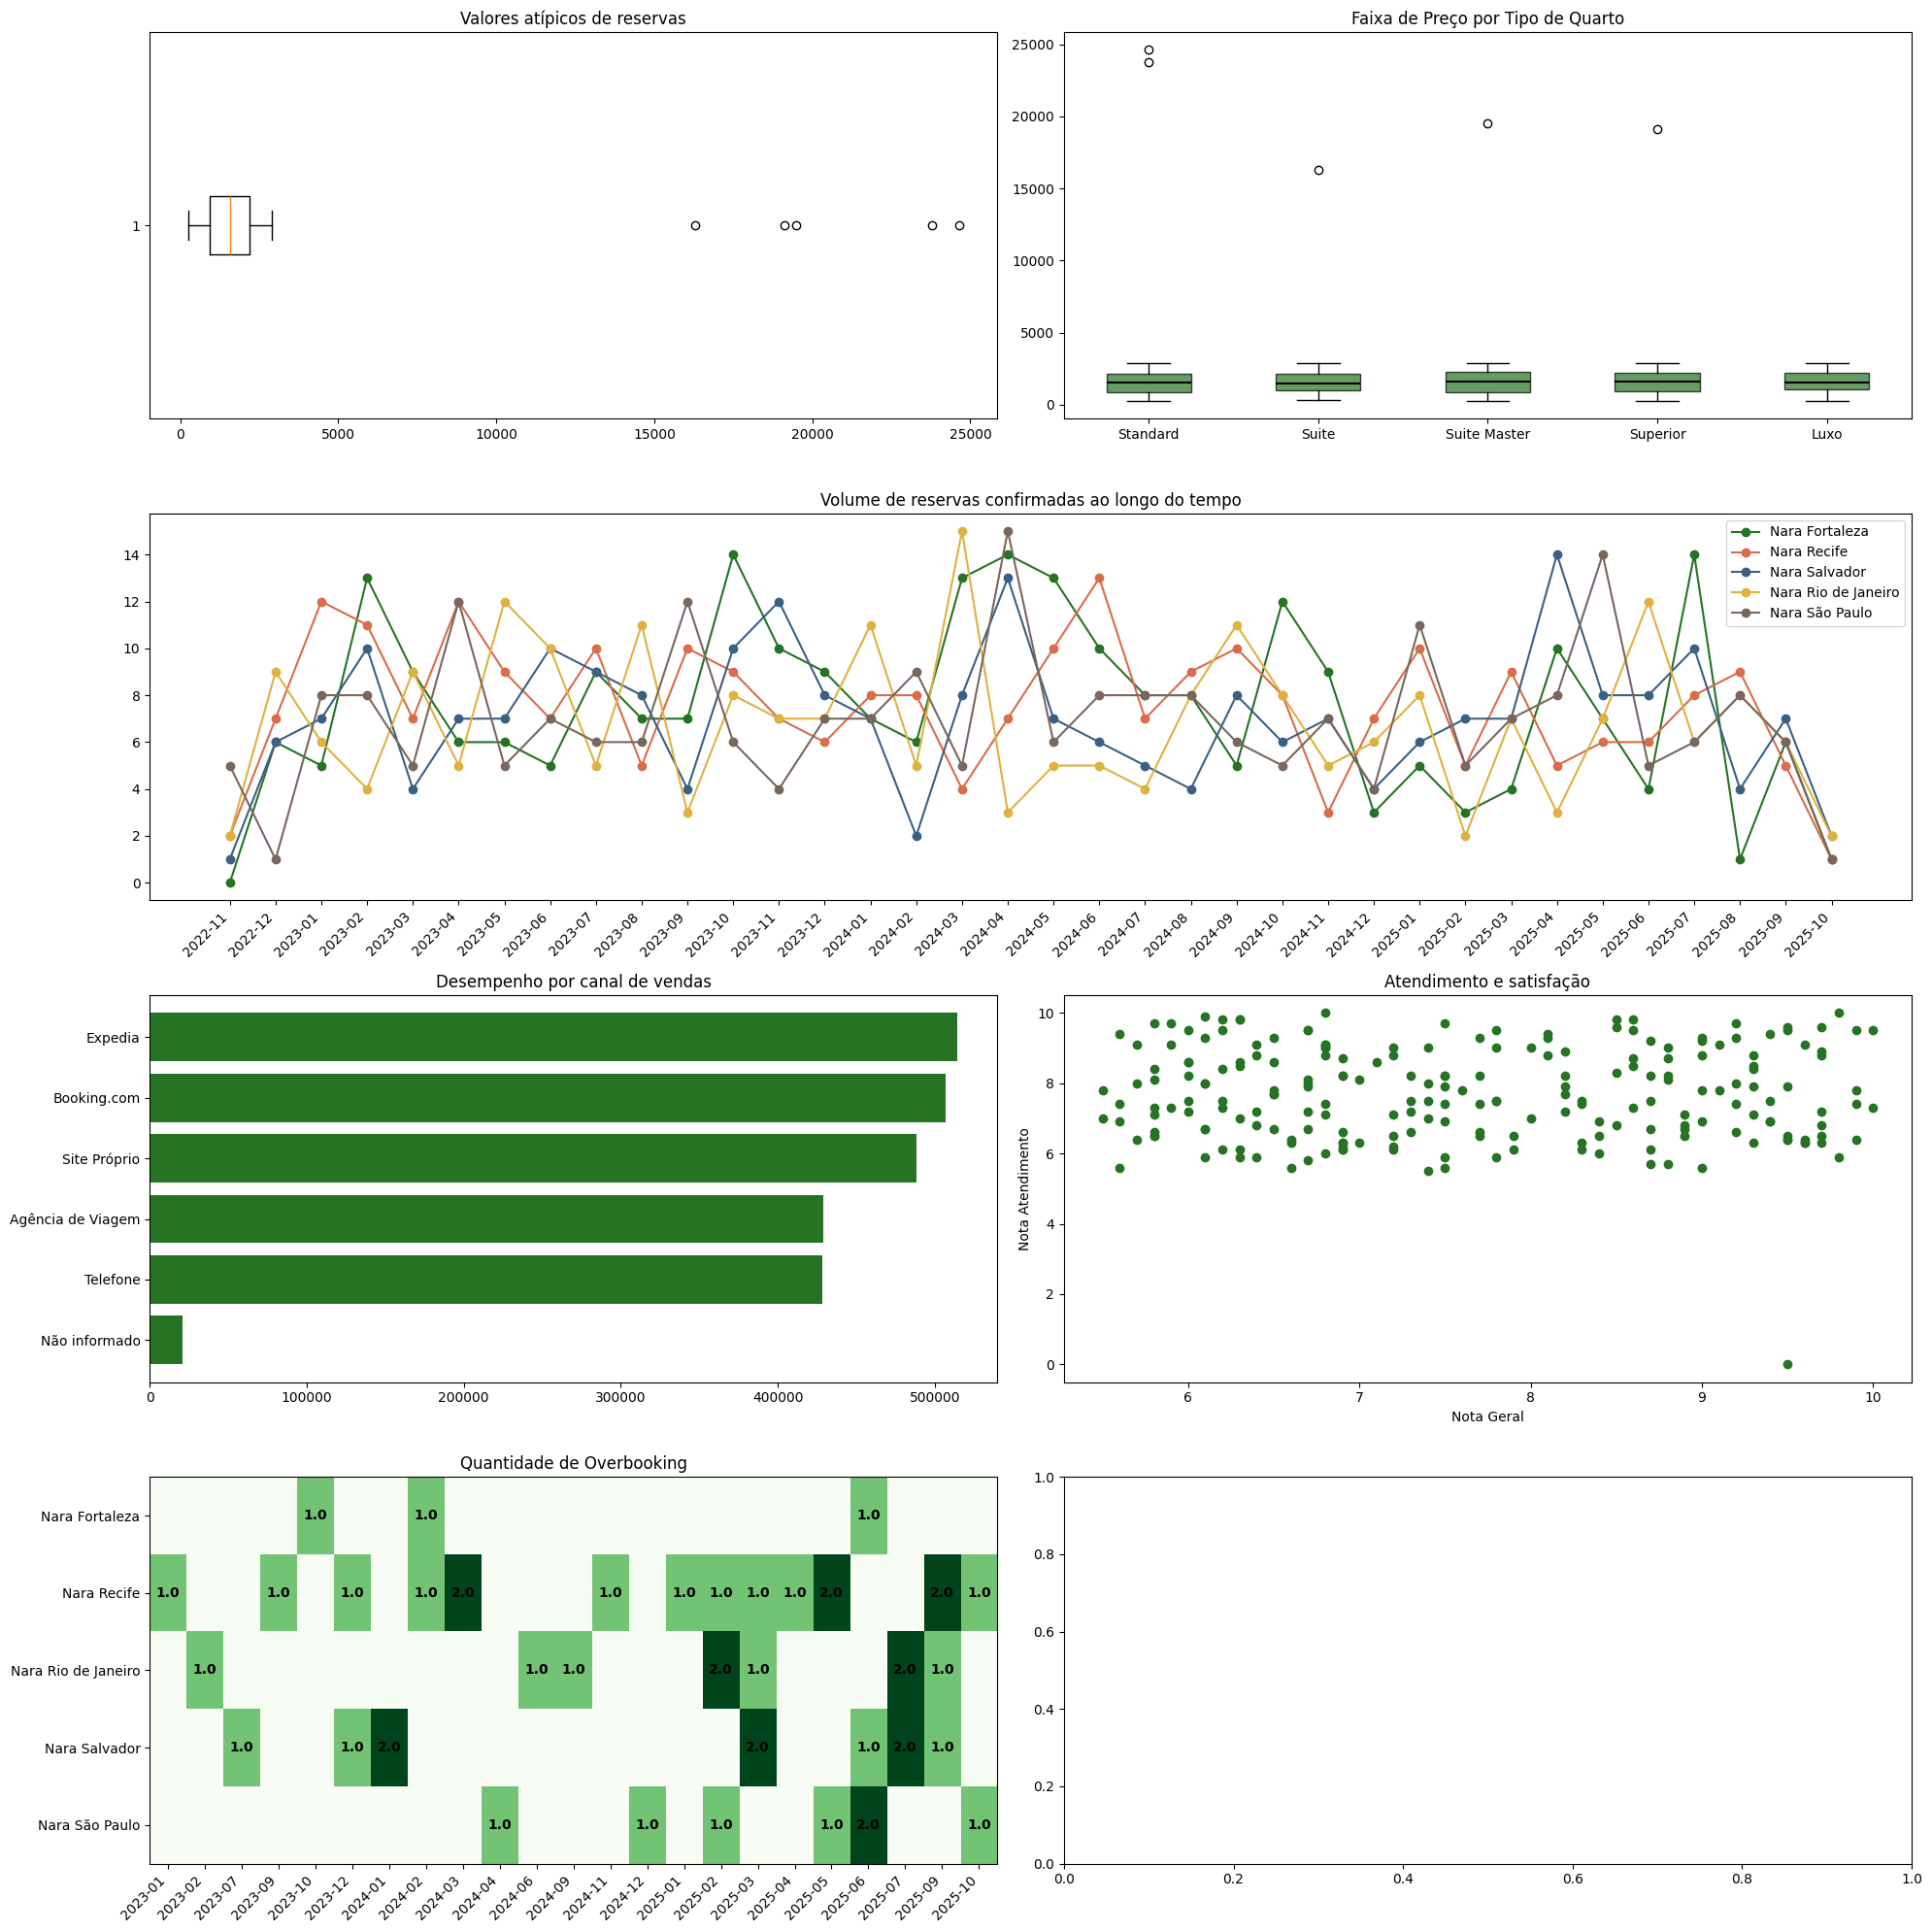

In [248]:
layout = [
    ['A', 'B'],
    ['C', 'C'],
    ['D', 'E'],
    ['F', 'G']
]

fig, axs = plt.subplot_mosaic(layout, figsize=(20, 20))

meses = tabela_linha_tempo.index
imagem = axs['F'].imshow(tabela_overbooking, cmap='Greens', aspect='auto')

axs['A'].boxplot(es.cria_array(reservas, 'valor_diaria'), vert=False)
caixas = axs['B'].boxplot(dados_para_boxplot, tick_labels=tipos_quarto, patch_artist=True)
for box in caixas['boxes']:
    box.set_facecolor('#267324')
    box.set_alpha(0.7)
    box.set_edgecolor('black')

for median in caixas['medians']:
    median.set_color('black')
    median.set_linewidth(1.5)

axs['C'].plot(meses, tabela_linha_tempo[1], marker='o', color='#267324', label='Nara Fortaleza')
axs['C'].plot(meses, tabela_linha_tempo[2], marker='o', color="#d96c4a", label='Nara Recife')
axs['C'].plot(meses, tabela_linha_tempo[3], marker='o', color="#3a6084", label='Nara Salvador')
axs['C'].plot(meses, tabela_linha_tempo[4], marker='o', color="#dfb141", label='Nara Rio de Janeiro')
axs['C'].plot(meses, tabela_linha_tempo[5], marker='o', color="#7a665d", label='Nara São Paulo')
axs['D'].barh(canal_maior_ticket['canal_reserva'], canal_maior_ticket['valor_diaria'], color='#267324')
axs['E'].scatter(avaliacoes['nota_geral'], avaliacoes['nota_atendimento'], color='#267324')
for i in range(len(tabela_overbooking.index)):
    for j in range(len(tabela_overbooking.columns)):
        valor = tabela_overbooking.iloc[i, j]
        if valor > 0:
            axs['F'].text(j, i, valor, ha="center", va="center", color="black", fontweight='bold')

axs['A'].set_title('Valores atípicos de reservas')
axs['B'].set_title('Faixa de Preço por Tipo de Quarto')
axs['C'].set_title('Volume de reservas confirmadas ao longo do tempo')
axs['C'].legend()
axs['D'].set_title('Desempenho por canal de vendas')
axs['E'].set_title('Atendimento e satisfação')
axs['E'].set_xlabel('Nota Geral')
axs['E'].set_ylabel('Nota Atendimento')
axs['F'].set_title('Quantidade de Overbooking')
axs['F'].set_xticks(range(len(tabela_overbooking.columns)))
axs['F'].set_xticklabels(tabela_overbooking.columns)
axs['F'].set_yticks(range(len(tabela_overbooking.index)))
axs['F'].set_yticklabels(tabela_overbooking.index)

plt.setp(axs['C'].get_xticklabels(), rotation=45, ha='right')
plt.setp(axs['F'].get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()